# <span style="color:darkblue"> Lecture 10b - Word Clouds </span>

<font size = "5">

In  this lecture we will work with text data

- Basic summary and data manipulation
- Generate word clouds!

# <span style="color:darkblue"> I. Import Libraries and Data </span>

<font size = "5">

Start by installing "wordcloud" using <br>
conda install in your terminal

<font size = "5">

Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud, STOPWORDS

<font size = "5">

Import Data

- Congressional bills in the United States

In [2]:
bills_actions = pd.read_csv("data_raw/bills_actions.csv")
bills_actions.dtypes

Congress       int64
bill_number    int64
bill_type        str
action           str
main_action      str
category         str
member_id      int64
dtype: object

# <span style="color:darkblue"> II. Word Clouds from Single Strings  </span>

<font size = "5">

Word Cloud from sentence

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

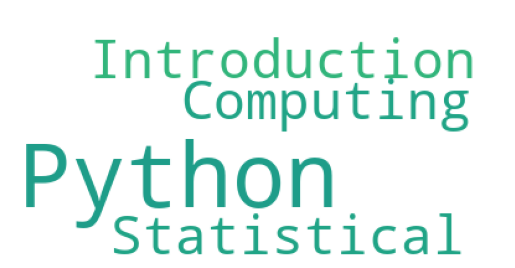

In [6]:
# We start by generating a string with text
# The WordCloud() command generates an object. To display it use "plt.imgshow()"
# Words with higher frequency will tend to appear larger (see advanced options)
# at the end for how to adjust the relative scaling

text = "Introduction to Statistical Computing Python Python Python Python Python"
word_cloud = WordCloud(background_color = "white").generate(text)
plt.imshow(word_cloud)
plt.axis("off")

<font size = "5">

Get word frequencies

In [7]:
word_frequencies = WordCloud().process_text(text)
word_frequencies

{'Introduction': 1, 'Statistical': 1, 'Computing': 1, 'Python': 5}

<font size = "5">

Adding stop words

- WordCloud drops common words like "to, from, the, a, ..."
- They're stored in STOPWORDS. We can add more!

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

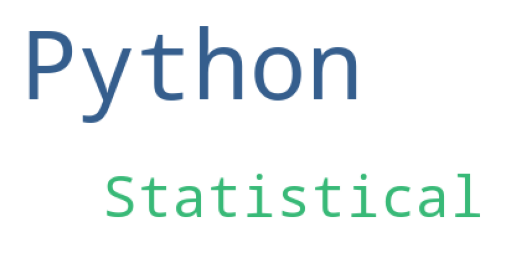

In [8]:
# Create adjusted list of stop words

stop_words = list(STOPWORDS) + ["Introduction","Computing"]
text = "Introduction to Statistical Computing Python Python Python Python Python"

# Plot results
# If you don't wan't any stopwords, use "stopwords = []" instead
word_cloud = WordCloud(background_color = "white",
                       stopwords = stop_words).generate(text)
plt.imshow(word_cloud)
plt.axis("off")

<font size = "5">

Try it yourself!

- Search in Wikipedia for an article.
- Copy a paragraph into Python and store it as <br>
a string variable called "text".
- Display a word cloud!

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

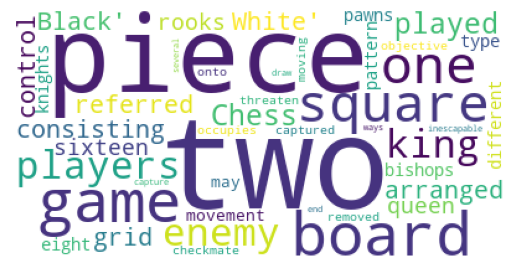

In [10]:
# Write your own code

text = "Chess is a board game for two players, played on a square board consisting of 64 squares \
    arranged in an 8×8 grid. The players, referred to as 'White' and 'Black', each control sixteen \
        pieces: one king, one queen, two rooks, two bishops, two knights, and eight pawns, with each \
            piece type having a different pattern of movement. An enemy piece may be captured \
                (removed from the board) by moving one's own piece onto the square it occupies. \
The objective of the game is to checkmate (threaten with inescapable capture) the enemy king. \
    There are also several ways a game can end in a draw."

word_cloud = WordCloud(background_color = "white").generate(text)
plt.imshow(word_cloud)
plt.axis("off")

# <span style="color:darkblue"> III. Word Clouds + Pandas </span>

<font size = "5">

Concatanate column into single long sentence

In [11]:
# We start of with an empty string and sequentiall
# concatenate all the elements of bills["main_action"] together

list_categories = ["house bill","senate bill"]
bills = bills_actions.query('category in @list_categories')

text_bills = "".join(bills["action"])

<font size = "5">

Create WordCloud

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

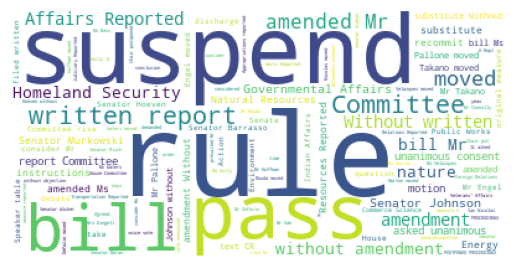

In [12]:
#stopwords = list(STOPWORDS) + ["Introduction","Computing"]
#text = "Introduction to Statistical Computing Python Python Python Python Python"

word_cloud = WordCloud(background_color = "white").generate(text_bills)
                       
plt.imshow(word_cloud)
plt.axis("off")

<font size = "5">

Text by subgroup

In [14]:
# Create sets of words by category
subset_bills_house  = bills_actions.query('category == "house bill"')
subset_bills_senate = bills_actions.query('category == "senate bill"')

# Create strings with all the words mentioned for those observations
text_house  = "".join(subset_bills_house["action"])
text_senate = "".join(subset_bills_senate["action"])

<font size = "5" >
Plotting multiple wordclouds

Text(0.5, 1.0, 'Senate')

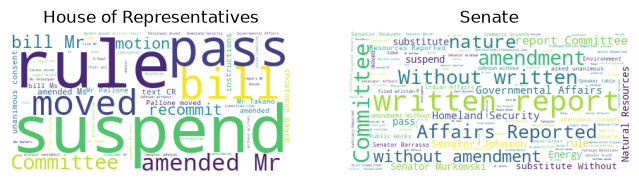

In [15]:
# Use subplots to create figures with multiple plots
fig, list_subfig = plt.subplots(1,2,figsize = [8,3])

word_cloud_house = WordCloud(background_color = "white").generate(text_house)                       
list_subfig[0].imshow(word_cloud_house)
list_subfig[0].axis("off")
list_subfig[0].set_title("House of Representatives")

word_cloud_senate = WordCloud(background_color = "white").generate(text_senate)                       
list_subfig[1].imshow(word_cloud_senate)
list_subfig[1].axis("off")
list_subfig[1].set_title("Senate")

<font size = "5">

**Note:** In general, many possibilities for splitting by subgroups! <br>
Years, geography, type of speaker, type of document, etc.

<font size = "5">
Try it yourself!

- Obtain the text for the categories "house resolution" <br>
and "senate resolution" (separately)
- Plot word clouds for the column "action" for each of the <br>
two categories using ``` plt.subplots()``` and the code <br>
shown above


Text(0.5, 1.0, 'Senate')

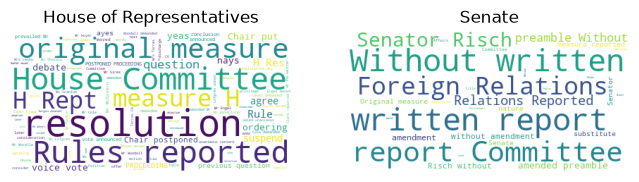

In [17]:
# Write your own code

res_categories = ["house resolution","senate resolution"]
resolutions = bills_actions.query('category in @res_categories')

# Verify that the code worked:
resolutions["category"].value_counts()

# Create sets of words by category
subset_resolution_house  = bills_actions.query('category == "house resolution"')
subset_resolution_senate = bills_actions.query('category == "senate resolution"')

# Create strings with all the words mentioned for those observations
text_house  = "".join(subset_resolution_house["action"])
text_senate = "".join(subset_resolution_senate["action"])

fig, list_subfig = plt.subplots(1,2,figsize = [8,3])

word_cloud_house = WordCloud(background_color = "white").generate(text_house)                       
list_subfig[0].imshow(word_cloud_house)
list_subfig[0].axis("off")
list_subfig[0].set_title("House of Representatives")

word_cloud_senate = WordCloud(background_color = "white").generate(text_senate)                       
list_subfig[1].imshow(word_cloud_senate)
list_subfig[1].axis("off")
list_subfig[1].set_title("Senate")


# <span style="color:darkblue"> V. (Optional) Advanced Settings </span>

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

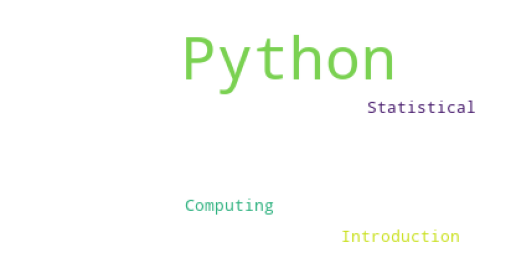

In [16]:
# Relative scaling of high-frequency words

text = "Introduction to Statistical Computing Python Python Python Python Python"
word_cloud = WordCloud(width = 400,
                       height = 200,
                       relative_scaling = 0.9, # or "auto"
                       background_color = "white").generate(text)
plt.imshow(word_cloud)
plt.axis("off")